# Feature analysis

## 1 Load data

### 1.1 load data from notebook 1

In [1]:
import pandas as pd
import numpy as np

team_seasons = pd.read_csv("../data/processed/team_seasons.csv")

team_seasons.shape

(2836, 24)

### 1.2 load new data

In [2]:
tourney_results = pd.read_csv("../data/raw/MNCAATourneyCompactResults.csv")

teams = pd.read_csv( "../data/raw/MTeams.csv")

## 2 inspect tourment results

In [5]:
tourney_results.shape

(2585, 8)

In [4]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [3]:
tourney_results.columns

Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT'],
      dtype='object')

In [11]:
teams.shape

(381, 4)

In [12]:
teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


In [13]:
teams.columns

Index(['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season'], dtype='object')

## 3 Clean tourtment results

### 3.1 fix years

In [14]:
years = [2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]

tourney_results = tourney_results[tourney_results["Season"].isin(years)].copy()

In [15]:
tourney_results.shape

(535, 8)

In [16]:
tourney_results["Season"].value_counts().sort_index()

Season
2016    67
2017    67
2018    67
2019    67
2021    66
2022    67
2023    67
2024    67
Name: count, dtype: int64

### 3.2 Standardize Team Name Formatting

In [18]:
team_name_lookup = dict(zip(teams["TeamID"], teams["TeamName"]))

In [19]:
tourney_results["WTeam"] = tourney_results["WTeamID"].map(team_name_lookup)
tourney_results["LTeam"] = tourney_results["LTeamID"].map(team_name_lookup)

In [20]:
tourney_results[["Season", "WTeam", "WScore", "LTeam", "LScore"]].head(10)

,Season,WTeam,WScore,LTeam,LScore
1983,2016,FGCU,96,F Dickinson,65
1984,2016,Wichita St,70,Vanderbilt,50
1985,2016,Holy Cross,59,Southern Univ,55
1986,2016,Michigan,67,Tulsa,62
1987,2016,Ark Little Rock,85,Purdue,83
1988,2016,Butler,71,Texas Tech,61
1989,2016,Connecticut,74,Colorado,67
1990,2016,Duke,93,UNC Wilmington,85
1991,2016,Gonzaga,68,Seton Hall,52
1992,2016,Indiana,99,Chattanooga,74


In [21]:
tourney_results[["WTeam", "LTeam"]].isna().sum()

WTeam    0
LTeam    0
dtype: int64

### 3.3  Identify Unmatched Team Names

In [22]:
#gettingevery unique tourtment team 
tournament_teams = set(tourney_results["WTeam"]) | set(tourney_results["LTeam"])

season_teams = set(team_seasons["TEAM"])

In [23]:
#find teams not in team_seassons data set
unmatched_teams = sorted(tournament_teams - season_teams)

len(unmatched_teams)

66

In [24]:
unmatched_teams

['Abilene Chr',
 'Appalachian St',
 'Arizona St',
 'Ark Little Rock',
 'Boise St',
 'CS Bakersfield',
 'CS Fullerton',
 'Cleveland St',
 'Col Charleston',
 'Colorado St',
 'E Washington',
 'ETSU',
 'F Dickinson',
 'FGCU',
 'FL Atlantic',
 'Florida St',
 'Fresno St',
 'Georgia St',
 'Grambling',
 'Iowa St',
 'Jacksonville St',
 'Kansas St',
 'Kennesaw',
 'Kent',
 'Long Beach St',
 'Louisiana',
 'Loyola-Chicago',
 'MTSU',
 'McNeese St',
 'Michigan St',
 'Mississippi St',
 'Montana St',
 'Morehead St',
 "Mt St Mary's",
 'Murray St',
 'N Dakota St',
 'N Kentucky',
 'NC Central',
 'NC State',
 'New Mexico St',
 'Norfolk St',
 'Ohio St',
 'Oklahoma St',
 'Oregon St',
 'Penn St',
 'Prairie View',
 'S Dakota St',
 'SE Missouri St',
 'SF Austin',
 'San Diego St',
 'Southern Univ',
 'St Bonaventure',
 "St John's",
 "St Joseph's PA",
 'St Louis',
 "St Mary's CA",
 "St Peter's",
 'TAM C. Christi',
 'TX Southern',
 'Utah St',
 'WI Green Bay',
 'WKU',
 'Washington St',
 'Weber St',
 'Wichita St',
 '

### 3.4 Investigate Team Name Differences

In [26]:
#making year spesific mapping
unmatched_pairs = []

for _, row in tourney_results.iterrows():
    for team in [row["WTeam"], row["LTeam"]]:
        year = row["Season"]

        match = team_seasons[
            (team_seasons["YEAR"] == year) &
            (team_seasons["TEAM"] == team)
        ]

        if match.empty:
            unmatched_pairs.append((year, team))

unmatched_pairs = sorted(set(unmatched_pairs))

len(unmatched_pairs)

154

In [27]:
unmatched_pairs

[(2016, 'Ark Little Rock'),
 (2016, 'CS Bakersfield'),
 (2016, 'F Dickinson'),
 (2016, 'FGCU'),
 (2016, 'Fresno St'),
 (2016, 'Iowa St'),
 (2016, 'MTSU'),
 (2016, 'Michigan St'),
 (2016, 'Oregon St'),
 (2016, 'S Dakota St'),
 (2016, 'SF Austin'),
 (2016, 'Southern Univ'),
 (2016, "St Joseph's PA"),
 (2016, 'WI Green Bay'),
 (2016, 'Weber St'),
 (2016, 'Wichita St'),
 (2017, 'ETSU'),
 (2017, 'FGCU'),
 (2017, 'Florida St'),
 (2017, 'Iowa St'),
 (2017, 'Jacksonville St'),
 (2017, 'Kansas St'),
 (2017, 'Kent'),
 (2017, 'MTSU'),
 (2017, 'Michigan St'),
 (2017, "Mt St Mary's"),
 (2017, 'N Kentucky'),
 (2017, 'NC Central'),
 (2017, 'New Mexico St'),
 (2017, 'Oklahoma St'),
 (2017, 'S Dakota St'),
 (2017, "St Mary's CA"),
 (2017, 'TX Southern'),
 (2017, 'Wichita St'),
 (2018, 'Arizona St'),
 (2018, 'CS Fullerton'),
 (2018, 'Col Charleston'),
 (2018, 'Florida St'),
 (2018, 'Georgia St'),
 (2018, 'Kansas St'),
 (2018, 'Loyola-Chicago'),
 (2018, 'Michigan St'),
 (2018, 'Murray St'),
 (2018, 'NC C

In [28]:
unmatched_names = sorted(set(team for year, team in unmatched_pairs))

len(unmatched_names), unmatched_names

(66,
 ['Abilene Chr',
  'Appalachian St',
  'Arizona St',
  'Ark Little Rock',
  'Boise St',
  'CS Bakersfield',
  'CS Fullerton',
  'Cleveland St',
  'Col Charleston',
  'Colorado St',
  'E Washington',
  'ETSU',
  'F Dickinson',
  'FGCU',
  'FL Atlantic',
  'Florida St',
  'Fresno St',
  'Georgia St',
  'Grambling',
  'Iowa St',
  'Jacksonville St',
  'Kansas St',
  'Kennesaw',
  'Kent',
  'Long Beach St',
  'Louisiana',
  'Loyola-Chicago',
  'MTSU',
  'McNeese St',
  'Michigan St',
  'Mississippi St',
  'Montana St',
  'Morehead St',
  "Mt St Mary's",
  'Murray St',
  'N Dakota St',
  'N Kentucky',
  'NC Central',
  'NC State',
  'New Mexico St',
  'Norfolk St',
  'Ohio St',
  'Oklahoma St',
  'Oregon St',
  'Penn St',
  'Prairie View',
  'S Dakota St',
  'SE Missouri St',
  'SF Austin',
  'San Diego St',
  'Southern Univ',
  'St Bonaventure',
  "St John's",
  "St Joseph's PA",
  'St Louis',
  "St Mary's CA",
  "St Peter's",
  'TAM C. Christi',
  'TX Southern',
  'Utah St',
  'WI Gr

In [29]:
from difflib import get_close_matches

for team in unmatched_names:
    years_for_team = [
        year for year, name in unmatched_pairs
        if name == team
    ]

    possible_names = team_seasons[team_seasons["YEAR"].isin(years_for_team)]["TEAM"].unique()

    matches = get_close_matches(team, possible_names, n=3,cutoff=0.5)

    print(team, "->", matches)

Abilene Chr -> ['Abilene Christian']
Appalachian St -> ['Appalachian St.', 'Michigan St.', 'Coppin St.']
Arizona St -> ['Arizona St.', 'Arizona', 'Oregon St.']
Ark Little Rock -> ['Arkansas Little Rock']
Boise St -> ['Boise St.', 'San Jose St.', 'Illinois St.']
CS Bakersfield -> ['Cal St. Bakersfield', 'Fairfield', 'UC Riverside']
CS Fullerton -> ['Cal St. Fullerton', 'Clemson', 'Southern']
Cleveland St -> ['Cleveland St.', 'Portland St.', 'Morehead St.']
Col Charleston -> ['College of Charleston', 'Charleston Southern', 'Coastal Carolina']
Colorado St -> ['Colorado St.', 'Colorado', 'Florida St.']
E Washington -> ['Washington', 'Eastern Washington', 'Washington St.']
ETSU -> ['TCU', 'SMU', 'LSU']
F Dickinson -> ['Fairleigh Dickinson', 'Davidson', 'Old Dominion']
FGCU -> ['VCU', 'TCU', 'FIU']
FL Atlantic -> ['Florida Atlantic']
Florida St -> ['Florida St.', 'Florida', 'Florida A&M']
Fresno St -> ['Fresno St.', 'Oregon St.', 'Sacramento St.']
Georgia St -> ['Georgia St.', 'Georgia', 'Ge

In [30]:
for team in unmatched_names:
    years_for_team = [
        year for year, name in unmatched_pairs
        if name == team
    ]

    print("\n", team, years_for_team)

    for year in years_for_team:
        names = team_seasons[
            team_seasons["YEAR"] == year
        ]["TEAM"].tolist()

        matches = get_close_matches(
            team,
            names,
            n=5,
            cutoff=0.3
        )

        print(year, matches)


 Abilene Chr [2019, 2021]
2019 ['Abilene Christian', 'Denver', 'College of Charleston', 'Winthrop', 'Tennessee Tech']
2021 ['Abilene Christian', 'Denver', 'College of Charleston', 'Winthrop', 'Tennessee Tech']

 Appalachian St [2021]
2021 ['Appalachian St.', 'Michigan St.', 'Coppin St.', 'Alcorn St.', 'Wichita St.']

 Arizona St [2018, 2019, 2023]
2018 ['Arizona St.', 'Arizona', 'Oregon St.', 'Alcorn St.', 'Montana St.']
2019 ['Arizona St.', 'Arizona', 'Oregon St.', 'Alcorn St.', 'Montana St.']
2023 ['Arizona St.', 'Arizona', 'Oregon St.', 'Alcorn St.', 'Montana St.']

 Ark Little Rock [2016]
2016 ['Arkansas Little Rock', 'Air Force', 'Arkansas Pine Bluff', 'Oral Roberts', 'Arkansas St.']

 Boise St [2022, 2023, 2024]
2022 ['Boise St.', 'San Jose St.', 'Illinois St.', 'Coppin St.', 'McNeese St.']
2023 ['Boise St.', 'San Jose St.', 'Illinois St.', 'Coppin St.', 'McNeese St.']
2024 ['Boise St.', 'San Jose St.', 'Illinois St.', 'Coppin St.', 'McNeese St.']

 CS Bakersfield [2016]
2016 ['

In [31]:
search_terms = [
    "Tennessee", "Florida Gulf", "Middle Tennessee",
    "Western Kentucky", "Carolina", "Louisiana",
    "Southern", "Green Bay"
]

for term in search_terms:
    print(
        term,
        sorted(
            team_seasons[
                team_seasons["TEAM"].str.contains(term, case=False, na=False)
            ]["TEAM"].unique()
        )
    )

Tennessee ['East Tennessee St.', 'Middle Tennessee', 'Tennessee', 'Tennessee Martin', 'Tennessee St.', 'Tennessee Tech']
Florida Gulf ['Florida Gulf Coast']
Middle Tennessee ['Middle Tennessee']
Western Kentucky ['Western Kentucky']
Carolina ['Coastal Carolina', 'East Carolina', 'North Carolina', 'North Carolina A&T', 'North Carolina Central', 'North Carolina St.', 'South Carolina', 'South Carolina St.', 'Western Carolina']
Louisiana ['Louisiana Lafayette', 'Louisiana Monroe', 'Louisiana Tech', 'Southeastern Louisiana']
Southern ['Charleston Southern', 'Georgia Southern', 'Southern', 'Southern Illinois', 'Southern Indiana', 'Southern Miss', 'Southern Utah', 'Texas Southern']
Green Bay ['Green Bay']


### 3.5 Create Team Name Mapping

In [32]:
tournament_name_map = {
    "ETSU": "East Tennessee St.",
    "FGCU": "Florida Gulf Coast",
    "MTSU": "Middle Tennessee",
    "WKU": "Western Kentucky",
    "NC State": "North Carolina St.",
    "WI Green Bay": "Green Bay",

    "Abilene Chr": "Abilene Christian",
    "Appalachian St": "Appalachian St.",
    "Arizona St": "Arizona St.",
    "Ark Little Rock": "Arkansas Little Rock",
    "Boise St": "Boise St.",
    "CS Bakersfield": "Cal St. Bakersfield",
    "CS Fullerton": "Cal St. Fullerton",
    "Cleveland St": "Cleveland St.",
    "Col Charleston": "College of Charleston",
    "Colorado St": "Colorado St.",
    "E Washington": "Eastern Washington",
    "F Dickinson": "Fairleigh Dickinson",
    "FL Atlantic": "Florida Atlantic",
    "Florida St": "Florida St.",
    "Fresno St": "Fresno St.",
    "Georgia St": "Georgia St.",
    "Grambling": "Grambling St.",
    "Iowa St": "Iowa St.",
    "Jacksonville St": "Jacksonville St.",
    "Kansas St": "Kansas St.",
    "Kennesaw": "Kennesaw St.",
    "Kent": "Kent St.",
    "Long Beach St": "Long Beach St.",
    "Louisiana": "Louisiana Lafayette",
    "Loyola-Chicago": "Loyola Chicago",
    "McNeese St": "McNeese St.",
    "Michigan St": "Michigan St.",
    "Mississippi St": "Mississippi St.",
    "Montana St": "Montana St.",
    "Morehead St": "Morehead St.",
    "Mt St Mary's": "Mount St. Mary's",
    "Murray St": "Murray St.",
    "N Dakota St": "North Dakota St.",
    "N Kentucky": "Northern Kentucky",
    "NC Central": "North Carolina Central",
    "New Mexico St": "New Mexico St.",
    "Norfolk St": "Norfolk St.",
    "Ohio St": "Ohio St.",
    "Oklahoma St": "Oklahoma St.",
    "Oregon St": "Oregon St.",
    "Penn St": "Penn St.",
    "Prairie View": "Prairie View A&M",
    "S Dakota St": "South Dakota St.",
    "SE Missouri St": "Southeast Missouri St.",
    "SF Austin": "Stephen F. Austin",
    "San Diego St": "San Diego St.",
    "Southern Univ": "Southern",
    "St Bonaventure": "St. Bonaventure",
    "St John's": "St. John's",
    "St Joseph's PA": "Saint Joseph's",
    "St Louis": "Saint Louis",
    "St Mary's CA": "Saint Mary's",
    "St Peter's": "Saint Peter's",
    "TAM C. Christi": "Texas A&M Corpus Chris",
    "TX Southern": "Texas Southern",
    "Utah St": "Utah St.",
    "Washington St": "Washington St.",
    "Weber St": "Weber St.",
    "Wichita St": "Wichita St.",
    "Wright St": "Wright St."
}

In [33]:
tourney_results["WTeam"] = tourney_results["WTeam"].replace(tournament_name_map)
tourney_results["LTeam"] = tourney_results["LTeam"].replace(tournament_name_map)

### 3.6 Apply Team Name Mapping

In [36]:
unmatched_pairs = []

for _, row in tourney_results.iterrows():
    for team in [row["WTeam"], row["LTeam"]]:
        year = row["Season"]

        match = team_seasons[
            (team_seasons["YEAR"] == year) &
            (team_seasons["TEAM"] == team)
        ]

        if match.empty:
            unmatched_pairs.append((year, team))

unmatched_pairs = sorted(set(unmatched_pairs))

len(unmatched_pairs), unmatched_pairs

(0, [])

In [38]:
tourney_results.columns

Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WTeam', 'LTeam'],
      dtype='object')

## 4. Match Tournament Teams to Team-Season Data

In [39]:
games = tourney_results[[
    "Season",
    "DayNum",
    "WTeam",
    "LTeam",
    "WScore",
    "LScore"
]].copy()

games = games.rename(columns={
    "Season": "YEAR"
})

games.head()

,YEAR,DayNum,WTeam,LTeam,WScore,LScore
1983,2016,134,Florida Gulf Coast,Fairleigh Dickinson,96,65
1984,2016,134,Wichita St.,Vanderbilt,70,50
1985,2016,135,Holy Cross,Southern,59,55
1986,2016,135,Michigan,Tulsa,67,62
1987,2016,136,Arkansas Little Rock,Purdue,85,83


In [40]:
print(games.shape)
print(games.isna().sum())

(535, 6)
YEAR      0
DayNum    0
WTeam     0
LTeam     0
WScore    0
LScore    0
dtype: int64


### 4.1 Attach Winning Team Statistics

In [42]:
winner_stats = team_seasons.add_prefix("W_")

games = games.merge(
    winner_stats,
    left_on=["WTeam", "YEAR"],
    right_on=["W_TEAM", "W_YEAR"],
    how="left",
    validate="many_to_one"
)

In [43]:
games.shape

(535, 30)

In [44]:
games[["WTeam", "YEAR", "W_TEAM", "W_YEAR"]].head()

,WTeam,YEAR,W_TEAM,W_YEAR
0,Florida Gulf Coast,2016,Florida Gulf Coast,2016
1,Wichita St.,2016,Wichita St.,2016
2,Holy Cross,2016,Holy Cross,2016
3,Michigan,2016,Michigan,2016
4,Arkansas Little Rock,2016,Arkansas Little Rock,2016


In [45]:
games["W_TEAM"].isna().sum()

np.int64(0)

### 4.2 attach loosing team statstics

In [46]:
loser_stats = team_seasons.add_prefix("L_")

games = games.merge(
    loser_stats,
    left_on=["LTeam", "YEAR"],
    right_on=["L_TEAM", "L_YEAR"],
    how="left",
    validate="many_to_one"
)

In [47]:
games["L_TEAM"].isna().sum()

np.int64(0)

In [48]:
games[[
    "YEAR",
    "WTeam",
    "LTeam",
    "W_SEED",
    "L_SEED",
    "W_POWER_RATING",
    "L_POWER_RATING"
]].head()

,YEAR,WTeam,LTeam,W_SEED,L_SEED,W_POWER_RATING,L_POWER_RATING
0,2016,Florida Gulf Coast,Fairleigh Dickinson,16.0,16.0,71.4,66.7
1,2016,Wichita St.,Vanderbilt,11.0,11.0,86.6,85.6
2,2016,Holy Cross,Southern,16.0,16.0,66.8,68.0
3,2016,Michigan,Tulsa,11.0,11.0,79.6,79.9
4,2016,Arkansas Little Rock,Purdue,12.0,5.0,78.9,88.7


## 5 Constrict matchup dataset

### 5.1 assign teams to a and b

In [49]:
#randomly assigntng historical winner to A or B using a fixed seed so I get same dataset everyinme
rng = np.random.default_rng(42)

winner_is_a = rng.integers(
    0,
    2,
    size=len(games)
).astype(bool)

In [50]:
#creating A and B targets
games["TEAM_A"] = np.where(
    winner_is_a,
    games["WTeam"],
    games["LTeam"]
)

games["TEAM_B"] = np.where(
    winner_is_a,
    games["LTeam"],
    games["WTeam"]
)

games["TEAM_A_WIN"] = winner_is_a.astype(int)

In [51]:
#checking A and B targets
games[[
    "YEAR",
    "WTeam",
    "LTeam",
    "TEAM_A",
    "TEAM_B",
    "TEAM_A_WIN"
]].head(10)

,YEAR,WTeam,LTeam,TEAM_A,TEAM_B,TEAM_A_WIN
0,2016,Florida Gulf Coast,Fairleigh Dickinson,Fairleigh Dickinson,Florida Gulf Coast,0
1,2016,Wichita St.,Vanderbilt,Wichita St.,Vanderbilt,1
2,2016,Holy Cross,Southern,Holy Cross,Southern,1
3,2016,Michigan,Tulsa,Tulsa,Michigan,0
4,2016,Arkansas Little Rock,Purdue,Purdue,Arkansas Little Rock,0
5,2016,Butler,Texas Tech,Butler,Texas Tech,1
6,2016,Connecticut,Colorado,Colorado,Connecticut,0
7,2016,Duke,UNC Wilmington,Duke,UNC Wilmington,1
8,2016,Gonzaga,Seton Hall,Seton Hall,Gonzaga,0
9,2016,Indiana,Chattanooga,Chattanooga,Indiana,0


In [52]:
games["TEAM_A_WIN"].value_counts()

TEAM_A_WIN
0    274
1    261
Name: count, dtype: int64

### 5.2 Assign Team Statistics to A and B

In [54]:
#adding seed
games["A_SEED"] = np.where(
    winner_is_a,
    games["W_SEED"],
    games["L_SEED"]
)

games["B_SEED"] = np.where(
    winner_is_a,
    games["L_SEED"],
    games["W_SEED"]
)

In [59]:
# adding power rating
games["A_POWER_RATING"] = np.where(
    winner_is_a,
    games["W_POWER_RATING"],
    games["L_POWER_RATING"]
)

games["B_POWER_RATING"] = np.where(
    winner_is_a,
    games["L_POWER_RATING"],
    games["W_POWER_RATING"]
)

In [60]:
#checking
games[[
    "TEAM_A",
    "TEAM_B",
    "A_SEED",
    "B_SEED",
    "A_POWER_RATING",
    "B_POWER_RATING",
    "TEAM_A_WIN"
]].head(10)

,TEAM_A,TEAM_B,A_SEED,B_SEED,A_POWER_RATING,B_POWER_RATING,TEAM_A_WIN
0,Fairleigh Dickinson,Florida Gulf Coast,16.0,16.0,66.7,71.4,0
1,Wichita St.,Vanderbilt,11.0,11.0,86.6,85.6,1
2,Holy Cross,Southern,16.0,16.0,66.8,68.0,1
3,Tulsa,Michigan,11.0,11.0,79.9,79.6,0
4,Purdue,Arkansas Little Rock,5.0,12.0,88.7,78.9,0
5,Butler,Texas Tech,9.0,8.0,84.2,81.3,1
6,Colorado,Connecticut,8.0,9.0,81.5,85.3,0
7,Duke,UNC Wilmington,4.0,13.0,87.3,77.7,1
8,Seton Hall,Gonzaga,6.0,11.0,84.5,86.0,0
9,Chattanooga,Indiana,12.0,5.0,76.6,87.4,0


In [61]:
# adding other stats
stat_cols = [
    col for col in team_seasons.columns
    if col not in ["TEAM", "YEAR"]
]

for col in stat_cols:
    games[f"A_{col}"] = np.where(
        winner_is_a,
        games[f"W_{col}"],
        games[f"L_{col}"]
    )

    games[f"B_{col}"] = np.where(
        winner_is_a,
        games[f"L_{col}"],
        games[f"W_{col}"]
    )

In [62]:
games[[
    "TEAM_A",
    "TEAM_B",
    "A_SEED",
    "B_SEED",
    "A_KADJ_O",
    "B_KADJ_O",
    "A_POWER_RATING",
    "B_POWER_RATING",
    "TEAM_A_WIN"
]].head()

,TEAM_A,TEAM_B,A_SEED,B_SEED,A_KADJ_O,B_KADJ_O,A_POWER_RATING,B_POWER_RATING,TEAM_A_WIN
0,Fairleigh Dickinson,Florida Gulf Coast,16.0,16.0,104.8360,102.917,66.7,71.4,0
1,Wichita St.,Vanderbilt,11.0,11.0,111.7430,114.458,86.6,85.6,1
2,Holy Cross,Southern,16.0,16.0,97.0369,100.906,66.8,68.0,1
3,Tulsa,Michigan,11.0,11.0,111.3520,115.094,79.9,79.6,0
4,Purdue,Arkansas Little Rock,5.0,12.0,117.0000,108.951,88.7,78.9,0


In [63]:
print(games.shape)
print(games.filter(regex="^A_").columns.tolist())
print(games.filter(regex="^B_").columns.tolist())

(535, 101)
['A_SEED', 'A_POWER_RATING', 'A_G', 'A_W', 'A_2P_O', 'A_2P_D', 'A_3P_O', 'A_3P_D', 'A_ADJ_T', 'A_WAB', 'A_KADJ_O', 'A_KADJ_D', 'A_BARTHAG', 'A_EFG%', 'A_EFG%D', 'A_TOV%', 'A_TOV%D', 'A_OREB%', 'A_DREB%', 'A_FTR', 'A_FTRD', 'A_AP_RANK']
['B_SEED', 'B_POWER_RATING', 'B_G', 'B_W', 'B_2P_O', 'B_2P_D', 'B_3P_O', 'B_3P_D', 'B_ADJ_T', 'B_WAB', 'B_KADJ_O', 'B_KADJ_D', 'B_BARTHAG', 'B_EFG%', 'B_EFG%D', 'B_TOV%', 'B_TOV%D', 'B_OREB%', 'B_DREB%', 'B_FTR', 'B_FTRD', 'B_AP_RANK']


## 6. Create Difference Features

### 6.1 Creating win Percentage

In [64]:
games["A_WIN_PCT"] = games["A_W"] / games["A_G"]
games["B_WIN_PCT"] = games["B_W"] / games["B_G"]

In [65]:
games[[
    "TEAM_A",
    "A_W",
    "A_G",
    "A_WIN_PCT",
    "TEAM_B",
    "B_W",
    "B_G",
    "B_WIN_PCT"
]].head()

,TEAM_A,A_W,A_G,A_WIN_PCT,TEAM_B,B_W,B_G,B_WIN_PCT
0,Fairleigh Dickinson,17,32,0.531250,Florida Gulf Coast,17,31,0.548387
1,Wichita St.,25,34,0.735294,Vanderbilt,19,33,0.575758
2,Holy Cross,15,35,0.428571,Southern,19,32,0.593750
3,Tulsa,20,32,0.625000,Michigan,22,35,0.628571
4,Purdue,26,35,0.742857,Arkansas Little Rock,28,33,0.848485


### 6.2 Create Statistical Differences

In [67]:
#creating difference for different usefull statistics
diff_stats = [
    "SEED",
    "WIN_PCT",
    "2P_O",
    "2P_D",
    "3P_O",
    "3P_D",
    "ADJ_T",
    "WAB",
    "KADJ_O",
    "KADJ_D",
    "BARTHAG",
    "EFG%",
    "EFG%D",
    "TOV%",
    "TOV%D",
    "OREB%",
    "DREB%",
    "FTR",
    "FTRD",
    "POWER_RATING",
    "AP_RANK"
]
for stat in diff_stats:
    games[f"{stat}_DIFF"] = games[f"A_{stat}"] - games[f"B_{stat}"]

### 6.3 Validate Difference Features

In [69]:
games[[
    "TEAM_A",
    "TEAM_B",
    "SEED_DIFF",
    "WIN_PCT_DIFF",
    "KADJ_O_DIFF",
    "KADJ_D_DIFF",
    "BARTHAG_DIFF",
    "POWER_RATING_DIFF",
    "TEAM_A_WIN"
]].head(10)

,TEAM_A,TEAM_B,SEED_DIFF,WIN_PCT_DIFF,KADJ_O_DIFF,KADJ_D_DIFF,BARTHAG_DIFF,POWER_RATING_DIFF,TEAM_A_WIN
0,Fairleigh Dickinson,Florida Gulf Coast,0.0,-0.017137,1.9190,10.2760,-0.239,-4.7,0
1,Wichita St.,Vanderbilt,0.0,0.159537,-2.7150,-3.9463,0.000,1.0,1
2,Holy Cross,Southern,0.0,-0.165179,-3.8691,2.3080,-0.100,-1.2,1
3,Tulsa,Michigan,0.0,-0.003571,-3.7420,-0.9760,-0.087,0.3,0
4,Purdue,Arkansas Little Rock,-7.0,-0.105628,8.0490,-3.2183,0.150,9.8,0
5,Butler,Texas Tech,1.0,0.072917,3.4720,2.3468,0.057,2.9,1
6,Colorado,Connecticut,-1.0,-0.058081,-2.8660,2.2958,-0.071,-3.8,0
7,Duke,UNC Wilmington,-9.0,-0.047491,11.7350,-1.0592,0.211,9.6,1
8,Seton Hall,Gonzaga,-5.0,-0.036134,-5.0070,-3.4003,-0.011,-1.5,0
9,Chattanooga,Indiana,7.0,0.046753,-13.6990,1.6795,-0.261,-10.8,0


In [70]:
diff_columns = [f"{stat}_DIFF" for stat in diff_stats]

print(len(diff_columns))
print(diff_columns)

21
['SEED_DIFF', 'WIN_PCT_DIFF', '2P_O_DIFF', '2P_D_DIFF', '3P_O_DIFF', '3P_D_DIFF', 'ADJ_T_DIFF', 'WAB_DIFF', 'KADJ_O_DIFF', 'KADJ_D_DIFF', 'BARTHAG_DIFF', 'EFG%_DIFF', 'EFG%D_DIFF', 'TOV%_DIFF', 'TOV%D_DIFF', 'OREB%_DIFF', 'DREB%_DIFF', 'FTR_DIFF', 'FTRD_DIFF', 'POWER_RATING_DIFF', 'AP_RANK_DIFF']


## 7. Check Missing Values

### 7.1 check missing values in difference 

In [71]:
missing_diff = games[diff_columns].isna().sum()

missing_diff[missing_diff > 0]

AP_RANK_DIFF    133
dtype: int64

In [72]:
missing_pct = (
    games[diff_columns].isna().mean() * 100
)

missing_pct[missing_pct > 0].sort_values(ascending=False)

AP_RANK_DIFF    24.859813
dtype: float64

### 7.2 Select Complete Model Features

#### AP_RANK_DIFF is excluded because approximately 25% of tournament matchups are missing AP ranking data. WIN_PCT_DIFF is excluded because the CBB season totals include postseason games, which could introduce data leakage when predicting earlier tournament games. A pre-tournament win percentage will be investigated in a later analysis.

In [83]:
model_features = [
    col for col in diff_columns
    if col not in ["AP_RANK_DIFF", "WIN_PCT_DIFF"]
]
print(len(model_features))
print(games[model_features].isna().sum().sum())

19
0


## Section 9. Explore Matchup Features

### 9.1 Summary Statistics

In [84]:
games[model_features].describe().T

,count,mean,std,min,25%,50%,75%,max
SEED_DIFF,535.0,0.418692,7.495843,-15.0000,-5.00000,1.0000,7.0000,15.0000
2P_O_DIFF,535.0,-0.140374,4.504594,-17.9000,-3.00000,0.0000,3.0000,11.9000
2P_D_DIFF,535.0,-0.082991,4.020261,-13.3000,-2.85000,-0.1000,2.6000,12.4000
3P_O_DIFF,535.0,-0.271402,3.623853,-11.0000,-2.60000,-0.3000,2.1000,9.5000
3P_D_DIFF,535.0,0.132897,2.927194,-7.1000,-1.90000,0.1000,2.0000,9.1000
ADJ_T_DIFF,535.0,-0.199626,3.952954,-11.2000,-2.95000,-0.2000,2.5000,10.0000
WAB_DIFF,535.0,-0.330935,7.039371,-19.7000,-4.80000,-0.4000,3.8500,22.9000
KADJ_O_DIFF,535.0,-0.533704,8.737347,-25.7144,-5.72700,-0.2260,4.8420,25.7764
KADJ_D_DIFF,535.0,0.225354,7.360398,-23.6096,-4.00665,0.1342,5.1613,24.4589
BARTHAG_DIFF,535.0,-0.010660,0.209934,-0.6910,-0.09900,-0.0070,0.0725,0.7290


### 9.2 corrolation with winning

In [85]:
feature_correlations = (
    games[model_features + ["TEAM_A_WIN"]]
    .corr()["TEAM_A_WIN"]
    .drop("TEAM_A_WIN")
    .sort_values()
)

feature_correlations

SEED_DIFF           -0.440051
KADJ_D_DIFF         -0.338991
2P_D_DIFF           -0.177209
EFG%D_DIFF          -0.170924
TOV%_DIFF           -0.153969
3P_D_DIFF           -0.121328
FTRD_DIFF           -0.110387
FTR_DIFF            -0.106599
DREB%_DIFF          -0.011165
ADJ_T_DIFF          -0.009372
TOV%D_DIFF           0.028734
3P_O_DIFF            0.132346
OREB%_DIFF           0.177851
2P_O_DIFF            0.186488
EFG%_DIFF            0.200056
KADJ_O_DIFF          0.423180
BARTHAG_DIFF         0.437601
WAB_DIFF             0.448959
POWER_RATING_DIFF    0.473038
Name: TEAM_A_WIN, dtype: float64

### 9.3 vizualizing stong features

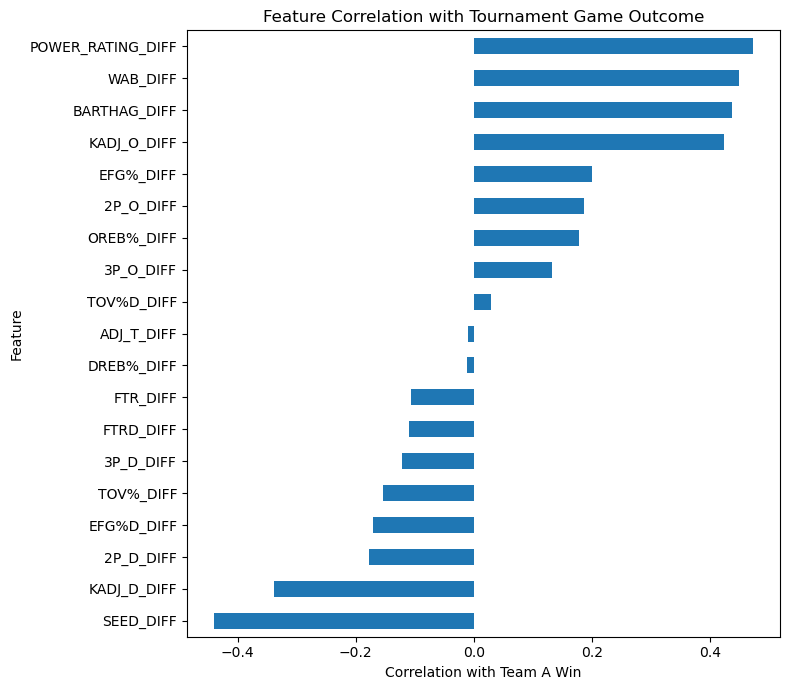

In [86]:
import matplotlib.pyplot as plt

feature_correlations.sort_values().plot(
    kind="barh",
    figsize=(8, 7)
)

plt.xlabel("Correlation with Team A Win")
plt.ylabel("Feature")
plt.title("Feature Correlation with Tournament Game Outcome")
plt.tight_layout()
plt.show()

## 10 review Target Varible

### 10.1 Target Distribution

In [87]:
target_counts = games["TEAM_A_WIN"].value_counts().sort_index()
target_pct = games["TEAM_A_WIN"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(target_counts)

print("\nPercentages:")
print(target_pct)

Counts:
TEAM_A_WIN
0    274
1    261
Name: count, dtype: int64

Percentages:
TEAM_A_WIN
0    51.214953
1    48.785047
Name: proportion, dtype: float64


In [ ]:
### add explination later 

## 11 Final data check

### 11.1 check dataset size

In [88]:
print("Games:", len(games))
print("Model features:", len(model_features))

Games: 535
Model features: 19


### 11.2 Check Missing Model Data

In [89]:
print("Missing model values:")
print(games[model_features].isna().sum().sum())

Missing model values:
0


### 11.3 check target

In [90]:
print("Missing targets:", games["TEAM_A_WIN"].isna().sum())
print("Target values:", sorted(games["TEAM_A_WIN"].unique()))

Missing targets: 0
Target values: [np.int64(0), np.int64(1)]


### 11.4 check duplacate games

In [91]:
games.duplicated(
    subset=["YEAR", "DayNum", "TEAM_A", "TEAM_B"]
).sum()

np.int64(0)

### 11.5 check seassons

In [92]:
sorted(games["YEAR"].unique())

[np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024)]

## 12 export matchups

### 12.1 create final dataset

In [93]:
final_columns = [
    "YEAR",
    "DayNum",
    "TEAM_A",
    "TEAM_B",
    "TEAM_A_WIN"
] + model_features

tournament_matchups = games[final_columns].copy()

tournament_matchups.head()

,YEAR,DayNum,TEAM_A,TEAM_B,TEAM_A_WIN,SEED_DIFF,2P_O_DIFF,2P_D_DIFF,3P_O_DIFF,3P_D_DIFF,...,BARTHAG_DIFF,EFG%_DIFF,EFG%D_DIFF,TOV%_DIFF,TOV%D_DIFF,OREB%_DIFF,DREB%_DIFF,FTR_DIFF,FTRD_DIFF,POWER_RATING_DIFF
0,2016,134,Fairleigh Dickinson,Florida Gulf Coast,0,0.0,-2.0,3.8,2.2,4.2,...,-0.239,0.4,3.9,1.0,4.8,-2.6,-8.5,-2.8,10.4,-4.7
1,2016,134,Wichita St.,Vanderbilt,1,0.0,-0.9,-0.5,-5.9,3.3,...,0.000,-3.9,1.4,-2.0,8.9,4.5,5.8,-1.7,11.2,1.0
2,2016,135,Holy Cross,Southern,1,0.0,-0.4,5.1,-1.2,3.5,...,-0.100,-0.8,5.5,0.3,0.5,-4.6,2.1,-2.6,-5.9,-1.2
3,2016,135,Tulsa,Michigan,0,0.0,-1.5,-6.1,-5.4,1.2,...,-0.087,-4.6,-2.9,0.8,2.9,3.6,-4.1,11.6,8.0,0.3
4,2016,136,Purdue,Arkansas Little Rock,0,-7.0,3.9,-2.8,-1.5,0.5,...,0.150,1.3,-0.8,1.6,-7.6,8.4,6.8,3.7,-10.6,9.8


### 12.2 final check

In [94]:
print(tournament_matchups.shape)
print(tournament_matchups.isna().sum().sum())

(535, 24)
0


### 13.3 export

In [95]:
tournament_matchups.to_csv(
    "../data/final/tournament_matchups.csv",
    index=False
)